# 03b. 수익률 예측 다시 설계하기

03에서는 어떤 모델도 수익률 RMSE에서 현재가 유지(Naive)를 넘지 못했다. 이 노트북은 같은 문제를 다른 방식으로 한 번 더 시험한다. 바꾸는 것은 세 가지다.

1. **고르는 방법(A)**: 해마다 그 전 해들의 성적으로 모델·설정을 고른다(중첩 검증). 03은 개발 구간 전체 성적으로 한 번 골랐다.
2. **예측 크기(B)**: 예측을 현재가 쪽으로 줄이는 비율 λ를 함께 고르고(B1), 수익률을 나누는 변동성 척도로 HAR 예측도 시험한다(B2).
3. **입력(C)**: 지평마다 다른 피처 묶음을 시험한다(C1). 기후는 산지별 29개 대신 나라별 요약을 쓰고(C2), 60일에는 거시의 긴 변화를 더한다(C3).

## 사전 등록 (계산 전에 고정, 2026-10-05)

**평가 구간**
- 개발 Test: 2012–2021년. 해마다 그 전까지의 자료로 학습해 그해를 예측한다(03과 같다).
- 재사용 확인: 2022–2025년. 03에서 이미 본 구간이라 결과는 기록만 하고 선택·채택에 쓰지 않는다.
- 사후 확인: 2026년(목표일 가격이 확인된 행). 진짜 평가는 동결 뒤 쌓이는 live 예측이다.

**고르는 방법 (A, B1)**
- 평가 연도 Y마다 안쪽 검증은 2009 … Y−1년이다. 각 해를 그 전까지의 자료로 학습해 예측한 값(확장 창 walk-forward)이고, 목표일이 Y−1년 말을 넘는 행은 뺀다.
- 후보마다 λ = Σ(예측 × 실제) / Σ(예측²)를 [0, 1]로 자른 값을 곱하고, 안쪽 검증 RMSE가 가장 작은 후보를 고른다. 어느 후보도 Naive보다 작지 않으면 Naive(예측 0)를 쓴다.
- 서비스 설정은 Y = 2026의 선택이다(안쪽 검증 2009–2025, 학습 2006–2025).

**후보**
- 모델: Ridge α ∈ {1, 10, 100, 1000, 10000}, LightGBM 트리 수 {100, 300} × 잎 수 {3, 7} × 잎의 최소 행 {50, 200}(학습률 0.03, 행·열 샘플링 0.8 고정).
- 변동성 척도(B2): 60일 변동성(지금 방식), HAR 예측 변동성(학습 구간에서 다시 맞춤).
- 피처 묶음(C1): 5일 {가격, 가격+단기 위험}, 20일 {가격, 가격+기후 요약}, 60일 {가격, 가격+기후 요약, 가격+기후 요약+거시 장기}.
- 단기 위험(2개): 5일·20일 변동성을 60일 변동성으로 나눈 값.
- 기후 요약(새 12개 + 기존 ENSO 2개): 브라질 3곳 평균(한파는 가장 추운 곳), 콜롬비아 3곳 평균.
  - a 표준화: 그 시기의 표준편차로 나눈 z.
  - b 평년값: 직전 10년의 같은 날짜 ±15일. 같은 달 평균은 달이 바뀔 때 기준이 뛴다.
  - c 사건: 최근 90일 가운데 브라질 90일 강수 z ≤ −1.5(SPI '심한 가뭄' 기준, McKee 외 1993)인 날 수, 콜롬비아 z ≥ +1.5인 날 수, 최근 30일 가운데 브라질 7일 최저기온 z ≤ −2인 날 수, ENSO 상태(ONI ≥ +0.5 엘니뇨, ≤ −0.5 라니냐, NOAA 기준). 여기 z는 감마분포 변환을 하지 않은 근사다.
  - d 생육기: 브라질 한파 z는 서리철(6–8월)에만, 30일 강수 z는 개화기(9–10월)에만 값을 두고 나머지 달은 0이다. 근거: 서리는 브라질 남부에서 6–8월에 드물지 않다(Perfect Daily Grind, 2021-07-29). 아라비카 개화는 9월이고 우기는 보통 9월에 시작한다(USDA FAS GAIN Coffee Annual BR2025-0013, 2025-05-19).
- 거시 장기(6개): 헤알 60·120일, 페소 60일, 금리 60일, WTI 60일, 운임 120일 변화.
- 모든 후보는 같은 행에서 비교한다. 기존 46개와 새 20개 피처가 직전 60거래일 동안 모두 있는 행이다.

**판단 규칙**
- 주 지표는 개발 Test RMSE다. 같은 행의 Naive, 그리고 현재 모델(03의 선택을 같은 행에서 다시 계산)과 비교하고 블록 bootstrap(블록 = h, 1,000회) 95% 구간을 낸다.
- 지평마다 새 방식의 개발 Test RMSE가 현재 모델보다 작으면 서비스에 새 방식을 쓴다. 'Naive보다 낫다'는 RMSE 차이 95% 구간의 상한이 0보다 작을 때만 쓴다.
- 단계별 효과(현재 → +λ → +튜닝 → +HAR 척도 → +지평별 묶음 → +거시 장기)와 기후 요약 단계(같은 달 원 편차 → b 날짜 평년값 → a z → c 사건 → d 생육기)는 설명용이다. 이 표를 보고 구성 요소를 빼거나 바꾸지 않는다.
- 결과를 본 뒤에는 후보·규칙·구간을 바꾸지 않는다. 바꿀 일이 생기면 다음 버전에서 새로 등록한다.

**바꾸지 않는 것**: 방향(상승 확률)·변동성 모델과 그 피처. 범위 배율 k는 04에서 새 예측 가격을 가운데에 두고 같은 규칙(개발 구간 적중률 80%)으로 다시 정한다.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import common
from coffee.config import DEV_YEARS, HOLDOUT_YEARS, HORIZONS, TRAIN_START
from coffee.evaluate import (FIRST_INNER_YEAR, apply_selection, block_bootstrap_rmse_diff, select_by_year,
                             usable_rows, walk_forward_predictions)
from coffee.features import (ALL_FEATURES, EXTRA_FEATURES, EXTRA_GROUPS, FEATURE_GROUPS, build_dataset,
                             climate_summary, daily_climatology, trailing_climatology, weather_rolling)
from coffee.models import return_model
from coffee.sources import load_sources

sources = load_sources()
data = build_dataset(sources)
ROW_FEATURES = ALL_FEATURES + EXTRA_FEATURES  # 모든 후보가 같은 행에서 겨룬다
YEARS = range(FIRST_INNER_YEAR, 2027)        # 2009–2026년을 해마다 그 전까지의 자료로 예측한다
OUTER_YEARS = range(DEV_YEARS[0], 2027)      # 2012–2026년을 해마다 고른다
PRICE, SHORT, MACRO_LONG = FEATURE_GROUPS["price"], EXTRA_GROUPS["short"], EXTRA_GROUPS["macro_long"]
ENSO = ["enso", "enso_chg_3m"]

# 기후 요약의 단계(설명용). v4가 서비스에 쓰는 묶음이다.
STEP_OPTIONS = {"v0": dict(normal="monthly", standardize=False, events=False, season=False),  # 같은 달 원 편차
                "v1": dict(normal="daily", standardize=False, events=False, season=False),    # + b 날짜 평년값
                "v2": dict(normal="daily", standardize=True, events=False, season=False),     # + a z
                "v3": dict(normal="daily", standardize=True, events=True, season=False)}      # + c 사건
CLIMATE = {}
for step, options in STEP_OPTIONS.items():
    frame = climate_summary(sources, data.index, **options).add_suffix(f"@{step}")
    data = data.join(frame)
    CLIMATE[step] = list(frame.columns) + ENSO
CLIMATE["v4"] = EXTRA_GROUPS["climate_summary"] + ENSO                                       # + d 생육기

for h in HORIZONS:
    before = usable_rows(data, ALL_FEATURES, h, TRAIN_START, "2026-12-31")
    rows = usable_rows(data, ROW_FEATURES, h, TRAIN_START, "2026-12-31")
    step_columns = sorted({name for names in CLIMATE.values() for name in names})
    assert not data.iloc[rows][step_columns].isna().any().any()  # 기후 단계 피처도 같은 행에서 모두 있다
    assert np.isfinite(data.iloc[rows][["log_vol_5", "log_vol_20", "log_vol_60"]].to_numpy()).all()
    print(f"{h}거래일: 03의 행 {len(before):,} → 03b의 행 {len(rows):,}")
print({step: len(names) for step, names in CLIMATE.items()}, "기후 요약 단계별 피처 수")

5거래일: 03의 행 5,033 → 03b의 행 4,953
20거래일: 03의 행 5,018 → 03b의 행 4,938
60거래일: 03의 행 4,978 → 03b의 행 4,898
{'v0': 8, 'v1': 8, 'v2': 8, 'v3': 12, 'v4': 14} 기후 요약 단계별 피처 수


새 피처를 넣으면 행이 1.6% 줄어든다. 페소(2013-09-23)와 WTI(2024-06-21–07-03)에 공백이 있어 60·120일 변화가 20일 변화보다 오래 결측이고, 직전 60거래일이 모두 있어야 하는 행 규칙이 그 뒤 60거래일을 더 뺀다. 결측은 채우지 않는다. 대신 현재 모델도 이 행에서 다시 계산해 같은 조건으로 비교한다.

## 1. 새 기후 요약 점검 (C2)

같은 달 평년값은 달이 바뀌는 날 한 번에 뛴다. 날짜 단위 평년값은 매끄럽게 움직인다. 결과(수익률)는 보지 않고 피처만 본다.

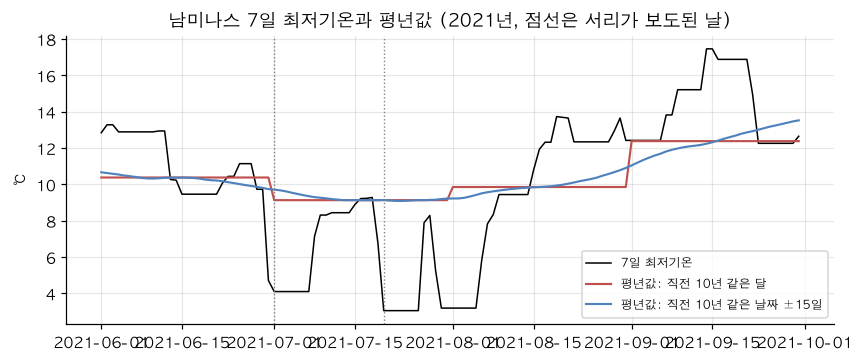

,br_rain90_z,br_drought_days90,br_tmin7_z,br_cold_days30,br_tmin7_z_frost,enso_state
2014-03-31 (가뭄),-3.29,81.0,-0.31,0.0,0.00,0.0
2021-07-26 (서리 반영 첫날),-1.09,0.0,-2.74,11.0,-2.74,0.0
2021-08-05,-1.06,0.0,-2.87,16.0,-2.87,0.0


In [2]:
rolled = weather_rolling(sources["weather_br_sul_minas"].set_index("date"))
monthly_normal = trailing_climatology(rolled)["tmin7"]
daily_normal = daily_climatology(rolled[["tmin7"]])[0]["tmin7"]
window = slice("2021-06-01", "2021-09-30")

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(rolled.loc[window, "tmin7"], color="black", lw=1, label="7일 최저기온")
ax.plot(monthly_normal.loc[window], color="#c0504d", lw=1.4, label="평년값: 직전 10년 같은 달")
ax.plot(daily_normal.loc[window], color="#4f81bd", lw=1.4, label="평년값: 직전 10년 같은 날짜 ±15일")
for day in ("2021-07-01", "2021-07-20"):
    ax.axvline(pd.Timestamp(day), color="gray", ls=":", lw=0.9)
ax.set(title="남미나스 7일 최저기온과 평년값 (2021년, 점선은 서리가 보도된 날)", ylabel="℃")
ax.legend(fontsize=8, loc="lower right")
common.save_fig(fig, "climate_normal_daily.png")
plt.show()

events = data.loc[["2014-03-31", "2021-07-26", "2021-08-05"],
                  ["br_rain90_z", "br_drought_days90", "br_tmin7_z", "br_cold_days30", "br_tmin7_z_frost", "enso_state"]]
events.index = ["2014-03-31 (가뭄)", "2021-07-26 (서리 반영 첫날)", "2021-08-05"]
events.round(2)

그림에서 같은 달 평년값(빨강)은 8월 1일에 한 번에 뛰지만(9.13 → 9.85℃), 날짜 단위 평년값(파랑)은 매끄럽게 움직인다(9.22 → 9.22℃). 사건 피처도 알려진 사건을 잡는다. 2014년 3월 말 브라질 90일 강수 z는 −3.29였고, 최근 90일 중 81일이 심한 가뭄 기준(z ≤ −1.5)을 넘었다. 2021년 서리는 기상 자료가 반영된 첫 거래일(7/26)에 한파 z −2.74로 나타났고, 7월 1일 서리를 포함해 최근 30일 중 11일이 한파 기준(z ≤ −2)을 넘었다.

## 2. 후보와 연도별 예측

후보마다 2009–2026년을 해마다 그 전까지의 자료로 학습해 예측해 둔다. 한 해의 예측은 그해 뒤의 선택과 상관없이 같으므로, 한 번 계산해 두고 연도마다 고를 때 다시 쓴다.

In [3]:
RIDGE = [("Ridge", {"alpha": a}) for a in (1, 10, 100, 1000, 10000)]
LIGHTGBM = [("LightGBM", {"n_estimators": n, "num_leaves": leaves, "min_child_samples": m})
            for n in (100, 300) for leaves in (3, 7) for m in (50, 200)]
SCALES = ("vol_60", "har")
CURRENT = {5: ("LightGBM", {"n_estimators": 150, "num_leaves": 7, "min_child_samples": 100}),
           20: ("LightGBM", {"n_estimators": 150, "num_leaves": 7, "min_child_samples": 100}),
           60: ("Ridge", {"alpha": 100})}  # 03의 선택: 가격 피처, 60일 변동성, 축소 없음


def feature_sets(h, step="v4", macro=True):
    climate = "가격+기후 요약" if step == "v4" else f"가격+기후 요약({step})"
    sets = {"가격": PRICE}
    if h == 5:
        sets["가격+단기 위험"] = PRICE + SHORT
    else:
        sets[climate] = PRICE + CLIMATE[step]
    if h == 60 and macro:
        sets[climate + "+거시 장기"] = PRICE + CLIMATE[step] + MACRO_LONG
    return sets


def candidates(sets, scales=SCALES, models=RIDGE + LIGHTGBM):
    out = {}
    for set_name, features in sets.items():
        for scale in scales:
            for name, params in models:
                label = f"{name}({', '.join(f'{k}={v}' for k, v in params.items())}) | {set_name} | {scale}"
                out[label] = {"model": name, "params": params, "feature_set": set_name, "features": features,
                              "scale": scale}
    return out


CONFIGS, predictions = {}, {}
for h in HORIZONS:
    name, params = CURRENT[h]
    CONFIGS[h] = {"현재 모델": {"model": name, "params": params, "feature_set": "가격", "features": PRICE, "scale": "vol_60"}}
    for step in CLIMATE:
        CONFIGS[h].update(candidates(feature_sets(h, step, macro=(step == "v4"))))
    predictions[h] = {label: walk_forward_predictions(
        data, lambda c=c: return_model(c["model"], c["features"], h, c["params"], c["scale"]), ROW_FEATURES, h, YEARS, 2026)
        for label, c in CONFIGS[h].items()}
    print(f"{h}거래일: 후보 {len(CONFIGS[h])}개")

5거래일: 후보 53개


20거래일: 후보 157개


60거래일: 후보 183개


## 3. 해마다 고르기

단계마다 후보 묶음을 넓혀 가며 같은 규칙(안쪽 검증 RMSE 최소, λ 포함)으로 고른다. 마지막 단계(+거시 장기)가 서비스 방식이다. 기후 요약 단계(v0–v3)는 '+지평별 묶음' 단계의 기후 묶음만 바꿔 본 것이다.

In [4]:
STAGES = {
    "+λ 축소(B1)": lambda h: {"현재 모델": CONFIGS[h]["현재 모델"]},
    "+튜닝(A)": lambda h: candidates({"가격": PRICE}, scales=("vol_60",)),
    "+HAR 척도(B2)": lambda h: candidates({"가격": PRICE}),
    "+지평별 묶음(C1·C2)": lambda h: candidates(feature_sets(h, "v4", macro=False)),
    "+거시 장기(C3)": lambda h: candidates(feature_sets(h, "v4")),
}
FINAL = "+거시 장기(C3)"
selections, outer = {}, {}
for h in HORIZONS:
    outer[h, "현재 모델"] = predictions[h]["현재 모델"]
    pools = {stage: make(h) for stage, make in STAGES.items()}
    pools.update({f"기후 {step}": candidates(feature_sets(h, step, macro=False)) for step in ("v0", "v1", "v2", "v3")})
    for stage, pool in pools.items():
        pool_predictions = {label: predictions[h][label] for label in pool}
        selections[h, stage] = select_by_year(data, h, pool_predictions, OUTER_YEARS)
        outer[h, stage] = apply_selection(data, pool_predictions, selections[h, stage])

chosen = pd.DataFrame({f"{h}거래일": selections[h, FINAL].apply(lambda r: f"{r['candidate']}  ×{r['weight']:.2f}", axis=1)
                       for h in HORIZONS})
chosen.index.name = "평가 연도"
chosen

,5거래일,20거래일,60거래일
평가 연도,,,
2012,"LightGBM(n_estimators=300, num_leaves=7, min_c...",Ridge(alpha=1) | 가격 | har ×0.25,Ridge(alpha=10000) | 가격 | har ×0.69
2013,Ridge(alpha=1) | 가격 | har ×0.19,"LightGBM(n_estimators=300, num_leaves=7, min_c...",Naive ×0.00
2014,Ridge(alpha=1) | 가격 | har ×0.17,"LightGBM(n_estimators=300, num_leaves=7, min_c...",Naive ×0.00
2015,Ridge(alpha=10) | 가격 | vol_60 ×0.32,Ridge(alpha=1) | 가격 | vol_60 ×0.28,Naive ×0.00
2016,Ridge(alpha=1) | 가격 | har ×0.43,Ridge(alpha=1) | 가격 | har ×0.42,Naive ×0.00
2017,Ridge(alpha=1) | 가격 | vol_60 ×0.42,"LightGBM(n_estimators=300, num_leaves=7, min_c...",Naive ×0.00
2018,Ridge(alpha=1) | 가격 | vol_60 ×0.44,"LightGBM(n_estimators=300, num_leaves=7, min_c...",Naive ×0.00
2019,Ridge(alpha=1) | 가격 | vol_60 ×0.42,"LightGBM(n_estimators=300, num_leaves=7, min_c...",Naive ×0.00
2020,Ridge(alpha=1) | 가격 | vol_60 ×0.34,"LightGBM(n_estimators=300, num_leaves=7, min_c...","LightGBM(n_estimators=300, num_leaves=7, min_c..."


고른 설정은 해마다 바뀐다. 5일은 2013–2021년에 대부분 Ridge(α=1)를 골랐고 λ는 0.17–0.44였다. 20일은 2017년부터 LightGBM(가격+기후 요약, HAR 척도)이 계속 뽑혔고 λ는 0.18–0.35였다. 60일은 2013–2019년과 2022년에 어떤 후보도 안쪽 검증에서 Naive보다 낫지 않아 Naive를 골랐다. 2020년부터 고른 LightGBM(가격+기후 요약)의 λ는 0.01–0.21로, 예측을 거의 다 줄였다. 거시 장기 묶음은 어느 해에도 뽑히지 않았다.

## 4. 결과

개발 Test가 판단 기준이다. 재사용 확인과 2026년은 이미 본 구간이라 참고로만 적는다.

In [5]:
PERIODS = {"개발 Test": (DEV_YEARS[0], DEV_YEARS[-1]), "재사용 확인": (HOLDOUT_YEARS[0], HOLDOUT_YEARS[-1]),
           "2026년": (2026, 2026)}


def period_rows(h, period):
    first, last = PERIODS[period]
    rows = predictions[h]["현재 모델"].index
    origin = data.index[rows]
    target = data[f"target_date_{h}"].to_numpy()[rows]
    keep = (origin.year >= first) & (origin.year <= last) & (target <= pd.Timestamp(f"{last}-12-31"))
    return rows[keep]


def score(h, pred, period, baseline=None):
    """Naive(또는 baseline) 대비 RMSE %와 그 차이의 블록 bootstrap 95% 구간(같은 단위 %)."""
    rows = period_rows(h, period)
    y, p = data[f"y_{h}"].to_numpy()[rows], pred.reindex(rows).to_numpy()
    base = np.zeros_like(y) if baseline is None else baseline.reindex(rows).to_numpy()
    rmse_base = np.sqrt(np.mean((y - base) ** 2))
    ci = block_bootstrap_rmse_diff(y, p, base, block=h)
    moved, said = y != 0, p != 0
    return {"행": len(rows), "RMSE 대비 %": 100 * (np.sqrt(np.mean((y - p) ** 2)) / rmse_base - 1),
            "95% 하한": 100 * ci["low"] / rmse_base, "95% 상한": 100 * ci["high"] / rmse_base,
            "방향 정확도(0 제외)": float(np.mean(np.sign(p[moved & said]) == np.sign(y[moved & said]))) if (moved & said).any() else np.nan,
            "예측 0 비율": float(np.mean(~said))}


stage_rows = []
for h in HORIZONS:
    for stage in ["현재 모델", *STAGES]:
        row = {"지평": h, "단계": stage}
        for period in PERIODS:
            s = score(h, outer[h, stage], period)
            row[f"{period} RMSE%"] = s["RMSE 대비 %"]
            if period == "개발 Test":
                row["개발 95% 구간"] = f"[{s['95% 하한']:+.2f}, {s['95% 상한']:+.2f}]"
                row["개발 예측 0 비율"] = s["예측 0 비율"]
        stage_rows.append(row)
stages = pd.DataFrame(stage_rows)
stages.set_index(["지평", "단계"]).round(2)

개발 Test RMSE%        개발 95% 구간  개발 예측 0 비율  재사용 확인 RMSE%  \
지평 단계                                                                         
5  현재 모델                    0.69   [-0.77, +2.21]        0.00          0.16   
   +λ 축소(B1)               -0.14   [-0.36, +0.07]        0.26         -0.27   
   +튜닝(A)                  -0.07   [-0.52, +0.42]        0.00         -0.18   
   +HAR 척도(B2)             -0.07   [-0.53, +0.44]        0.00         -0.18   
   +지평별 묶음(C1·C2)          -0.01   [-0.48, +0.49]        0.00         -0.18   
   +거시 장기(C3)              -0.01   [-0.48, +0.49]        0.00         -0.18   
20 현재 모델                    3.71   [-0.25, +7.92]        0.00          1.39   
   +λ 축소(B1)               -0.33   [-1.13, +0.49]        0.00         -0.36   
   +튜닝(A)                  -0.41   [-1.70, +0.93]        0.00         -0.44   
   +HAR 척도(B2)             -0.35   [-1.65, +1.10]        0.00         -0.44   
   +지평별 묶음(C1·C2)          -0.53   [-2.57, +1.69]        0.00         -0.21   
   +거시 장기(C3)              -0.53   [-2.57, +1.69]        0.00         -0.21   
60 현재 모델                    5.69  [+0.66, +10.52]        0.00          3.81   
   +λ 축소(B1)                0.00   [+0.00, +0.00]        1.00          0.00   
   +튜닝(A)                   1.32   [+0.14, +2.80]        0.89          0.00   
   +HAR 척도(B2)              1.43   [+0.15, +3.02]        0.89          0.00   
   +지평별 묶음(C1·C2)           3.59   [+0.86, +6.48]        0.70         -0.17   
   +거시 장기(C3)               3.59   [+0.86, +6.48]        0.70         -0.17   

                   2026년 RMSE%  
지평 단계                           
5  현재 모델                  0.20  
   +λ 축소(B1)             -0.30  
   +튜닝(A)                 0.07  
   +HAR 척도(B2)            0.07  
   +지평별 묶음(C1·C2)         0.07  
   +거시 장기(C3)             0.07  
20 현재 모델                 -2.50  
   +λ 축소(B1)             -0.89  
   +튜닝(A)                -0.78  
   +HAR 척도(B2)           -0.78  
   +지평별 묶음(C1·C2)        -0.10  
   +거시 장기(C3)            -0.10  
60 현재 모델                 -5.00  
   +λ 축소(B1)              0.00  
   +튜닝(A)                 0.00  
   +HAR 척도(B2)            0.00  
   +지평별 묶음(C1·C2)        -0.28  
   +거시 장기(C3)            -1.45

In [6]:
# 03에서 적은 현재 모델 성적(03의 행)과 03b의 행에서 다시 계산한 값
reported = common.load_result("return_selection")
pd.DataFrame({h: {"03의 행": reported[str(h)]["dev"]["rmse_vs_naive_pct"],
                  "03b의 행": score(h, outer[h, "현재 모델"], "개발 Test")["RMSE 대비 %"]} for h in HORIZONS}).round(2)

,5,20,60
03의 행,0.94,3.81,4.93
03b의 행,0.69,3.71,5.69


단계별로 보면 개선의 대부분은 λ 축소(B1)에서 나왔다. 현재 모델에 λ만 붙여도 개발 Test RMSE가 5일 +0.69% → −0.14%, 20일 +3.71% → −0.33%, 60일 +5.69% → 0.00%(해마다 λ = 0, 즉 Naive)가 됐다. 튜닝(A)과 HAR 척도(B2)는 5·20일에서 0.1%p 안팎으로 거의 바꾸지 못했다. 지평별 묶음(C1·C2)은 20일을 −0.53%로 조금 낮췄지만 5일은 그대로였고, 60일은 후보를 넓힐수록 나빠졌다(+1.32% → +1.43% → +3.59%). 거시 장기(C3)는 뽑히지 않아 결과가 같다.

03의 행과 03b의 행에서 현재 모델 성적이 다르다(5일 0.94% → 0.69%, 60일 4.93% → 5.69%). 행을 1.6%만 바꿔도 60일은 0.8%p 움직인다. 60일 숫자를 조심해서 읽어야 하는 이유다.

In [7]:
compare = []
for h in HORIZONS:
    for period in PERIODS:
        vs_naive = score(h, outer[h, FINAL], period)
        vs_current = score(h, outer[h, FINAL], period, baseline=outer[h, "현재 모델"])
        compare.append({"지평": h, "구간": period, "행": vs_naive["행"],
                        "Naive 대비 %": vs_naive["RMSE 대비 %"],
                        "Naive 대비 95% 구간": f"[{vs_naive['95% 하한']:+.2f}, {vs_naive['95% 상한']:+.2f}]",
                        "현재 모델 대비 %": vs_current["RMSE 대비 %"],
                        "현재 모델 대비 95% 구간": f"[{vs_current['95% 하한']:+.2f}, {vs_current['95% 상한']:+.2f}]",
                        "방향 정확도(0 제외)": vs_naive["방향 정확도(0 제외)"], "예측 0 비율": vs_naive["예측 0 비율"]})
compare = pd.DataFrame(compare)
compare.set_index(["지평", "구간"]).round(3)

행  Naive 대비 % Naive 대비 95% 구간  현재 모델 대비 % 현재 모델 대비 95% 구간  \
지평 구간                                                                      
5  개발 Test  2385      -0.014  [-0.48, +0.49]      -0.704  [-2.08, +0.57]   
   재사용 확인    871      -0.176  [-0.98, +0.62]      -0.333  [-2.67, +1.85]   
   2026년     184       0.075  [-1.15, +1.35]      -0.121  [-2.94, +2.66]   
20 개발 Test  2370      -0.526  [-2.57, +1.69]      -4.081  [-7.52, -0.79]   
   재사용 확인    856      -0.209  [-2.10, +1.68]      -1.577  [-4.59, +1.48]   
   2026년     169      -0.098  [-2.00, +1.95]       2.464  [-2.96, +8.26]   
60 개발 Test  2330       3.593  [+0.86, +6.48]      -1.987  [-6.56, +2.09]   
   재사용 확인    816      -0.169  [-0.54, +0.19]      -3.836  [-7.50, -0.78]   
   2026년     129      -1.452  [-3.28, +0.96]       3.733  [-0.94, +7.20]   

            방향 정확도(0 제외)  예측 0 비율  
지평 구간                              
5  개발 Test         0.501    0.000  
   재사용 확인          0.500    0.000  
   2026년           0.467    0.000  
20 개발 Test         0.571    0.000  
   재사용 확인          0.539    0.000  
   2026년           0.485    0.000  
60 개발 Test         0.361    0.702  
   재사용 확인          0.572    0.308  
   2026년           0.543    0.000

In [8]:
# 결과를 본 뒤 더한 설명용 표: 서비스 방식의 연도별 Naive 대비 RMSE % (개발 Test)
by_year = []
for h in HORIZONS:
    rows = period_rows(h, "개발 Test")
    origin, y_all = data.index[rows], data[f"y_{h}"].to_numpy()[rows]
    for year in DEV_YEARS:
        y, p = y_all[origin.year == year], outer[h, FINAL].reindex(rows[origin.year == year]).to_numpy()
        by_year.append({"지평": f"{h}거래일", "연도": year,
                        "Naive 대비 %": 100 * (np.sqrt(np.mean((y - p) ** 2)) / np.sqrt(np.mean(y ** 2)) - 1)})
pd.DataFrame(by_year).pivot(index="연도", columns="지평", values="Naive 대비 %")[[f"{h}거래일" for h in HORIZONS]].round(2)

지평,5거래일,20거래일,60거래일
연도,,,
2012,0.44,-0.95,11.75
2013,0.00,-3.22,0.00
2014,-0.58,-1.04,0.00
2015,-0.80,-3.97,0.00
2016,-0.69,-2.03,0.00
2017,-0.43,-6.61,0.00
2018,0.14,-0.04,0.00
2019,0.66,-4.14,0.00
2020,0.91,-3.04,-2.15


미리 정한 규칙대로 세 지평 모두 새 방식의 개발 Test RMSE가 현재 모델보다 작아 채택한다. 하지만 Naive보다 낫다고 말할 수 있는 지평은 없다. 5·20일은 Naive와 같은 수준(−0.01%, −0.53%)이고 95% 구간이 0을 포함한다. 60일은 Naive보다 3.59% 나쁘고 구간도 0보다 크다. 현재 모델보다 확실히 나아진 것은 20일(−4.1%, 구간 [−7.5, −0.8])뿐이다.

연도별로 보면 20일은 10년 중 9년 Naive보다 나았지만 2021년에 13.1% 나빴다. 60일은 2012년(+11.8%)과 2021년(+12.5%) 두 해가 오차를 만들었고, 2013–2019년은 Naive를 골라 Naive와 같았다. 2021년은 브라질 서리와 가격 급등이 있던 해다. 크게 움직이는 해에 방향을 놓치면 예측을 줄여도 손해가 크다.

재사용 확인(2022–2025)에서는 세 지평 모두 Naive와 거의 같았다(−0.18 / −0.21 / −0.17%). 2026년은 현재 모델이 20·60일에서 Naive보다 2.5%·5.0% 나았던 해인데, 새 방식은 −0.10%·−0.28%였다. 예측을 많이 줄였기 때문에 맞는 해의 이득도 작다. 두 구간 모두 이미 본 구간이라 판단에는 쓰지 않았다.

In [9]:
step_names = {"기후 v0": "같은 달 원 편차", "기후 v1": "+ b 날짜 평년값", "기후 v2": "+ a z",
              "기후 v3": "+ c 사건", "+지평별 묶음(C1·C2)": "+ d 생육기 (서비스)"}
climate_steps = pd.DataFrame([{"지평": h, "기후 요약 단계": label,
                               **{f"{period} RMSE%": score(h, outer[h, stage], period)["RMSE 대비 %"] for period in PERIODS}}
                              for h in (20, 60) for stage, label in step_names.items()])
climate_steps.set_index(["지평", "기후 요약 단계"]).round(2)

개발 Test RMSE%  재사용 확인 RMSE%  2026년 RMSE%
지평 기후 요약 단계                                               
20 같은 달 원 편차              -0.47         -1.13        -2.14
   + b 날짜 평년값             -0.07         -1.47        -2.49
   + a z                   1.17         -1.87        -0.89
   + c 사건                  1.28         -0.37         0.26
   + d 생육기 (서비스)          -0.53         -0.21        -0.10
60 같은 달 원 편차               2.41         -0.53        -1.22
   + b 날짜 평년값              2.22         -0.70        -1.50
   + a z                   3.55         -0.12        -0.43
   + c 사건                  3.61         -0.31        -0.25
   + d 생육기 (서비스)           3.59         -0.17        -0.28

기후 요약을 단계별로 바꿔 보면 효과가 일정하지 않다. 20일 개발 Test는 같은 달 원 편차 −0.47% → 날짜 평년값 −0.07% → z +1.17% → 사건 +1.28% → 생육기 −0.53%로 오르내렸고, 60일은 2.41% → 2.22% → 3.55% → 3.61% → 3.59%였다. 재사용 확인에서는 순서가 또 다르다. 차이는 모두 구간 폭(±2–3%p)보다 작다. 이상기후를 더 정확히 잡는 피처(b·a·c·d)가 수익률 예측을 확실히 낫게 했다는 근거는 없다. 규칙대로 서비스에는 마지막 단계(생육기까지)를 쓴다.

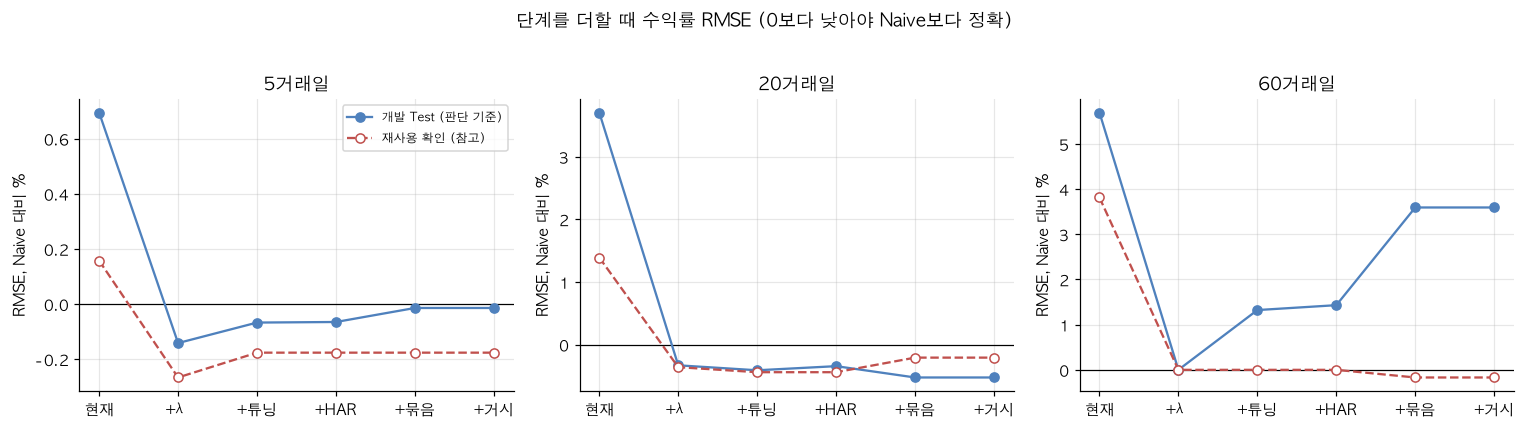

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=False)
order = ["현재 모델", *STAGES]
for ax, h in zip(axes, HORIZONS):
    table = stages[stages["지평"] == h].set_index("단계").loc[order]
    x = np.arange(len(order))
    ax.axhline(0, color="black", lw=0.8)
    ax.plot(x, table["개발 Test RMSE%"], marker="o", color="#4f81bd", label="개발 Test (판단 기준)")
    ax.plot(x, table["재사용 확인 RMSE%"], marker="o", ls="--", color="#c0504d", mfc="white", label="재사용 확인 (참고)")
    ax.set_xticks(x, ["현재", "+λ", "+튜닝", "+HAR", "+묶음", "+거시"])
    ax.set(title=f"{h}거래일", ylabel="RMSE, Naive 대비 %")
axes[0].legend(fontsize=8)
fig.suptitle("단계를 더할 때 수익률 RMSE (0보다 낮아야 Naive보다 정확)", y=1.02)
fig.tight_layout()
common.save_fig(fig, "return_redesign.png")
plt.show()

## 5. 서비스 설정과 채택

2026년의 선택(안쪽 검증 2009–2025)이 서비스 설정이다. 미리 정한 규칙대로 개발 Test RMSE가 현재 모델보다 작은 지평만 새 방식을 쓴다.

In [11]:
def config(h, label, weight):
    if label == "Naive":
        return {"candidate": "Naive", "weight": 0.0}
    c = CONFIGS[h][label]
    return {"candidate": label, "model": c["model"], "params": c["params"], "feature_set": c["feature_set"],
            "features": c["features"], "scale": c["scale"], "weight": float(weight)}


def summary(h, pred):
    out = {}
    for period, key in (("개발 Test", "dev"), ("재사용 확인", "holdout"), ("2026년", "forward")):
        s = score(h, pred, period)
        out[key] = {"rmse_vs_naive_pct": s["RMSE 대비 %"], "ci_low_pct": s["95% 하한"], "ci_high_pct": s["95% 상한"],
                    "direction_acc": s["방향 정확도(0 제외)"], "zero_share": s["예측 0 비율"], "rows": s["행"]}
    return out


redesign = {}
for h in HORIZONS:
    new, current = summary(h, outer[h, FINAL]), summary(h, outer[h, "현재 모델"])
    adopted = new["dev"]["rmse_vs_naive_pct"] < current["dev"]["rmse_vs_naive_pct"]
    by_year = {int(year): config(h, r["candidate"], r["weight"]) for year, r in selections[h, FINAL].iterrows()}
    redesign[str(h)] = {"adopted": bool(adopted), "final": by_year[2026], "by_year": by_year,
                        "new": new, "current": current}
    final = by_year[2026]
    print(f"{h}거래일: {'채택' if adopted else '현재 모델 유지'} — 개발 Test Naive 대비 {new['dev']['rmse_vs_naive_pct']:+.2f}% "
          f"(현재 모델 {current['dev']['rmse_vs_naive_pct']:+.2f}%), 서비스 설정 {final['candidate']} ×{final['weight']:.2f}")

common.save_result("return_redesign", {
    "row_features": "ALL_FEATURES + EXTRA_FEATURES", "first_inner_year": FIRST_INNER_YEAR,
    "horizons": redesign,
    "stages": stages.round(4).to_dict("records"),
    "climate_steps": climate_steps.round(4).to_dict("records"),
})

5거래일: 채택 — 개발 Test Naive 대비 -0.01% (현재 모델 +0.69%), 서비스 설정 Ridge(alpha=1) | 가격 | vol_60 ×0.29
20거래일: 채택 — 개발 Test Naive 대비 -0.53% (현재 모델 +3.71%), 서비스 설정 LightGBM(n_estimators=300, num_leaves=7, min_child_samples=50) | 가격+기후 요약 | har ×0.21


60거래일: 채택 — 개발 Test Naive 대비 +3.59% (현재 모델 +5.69%), 서비스 설정 Ridge(alpha=1000) | 가격+기후 요약+거시 장기 | har ×0.10


## 정리

- 중첩 검증, λ 축소, 튜닝, HAR 척도, 지평별 묶음, 기후 요약(a–d), 거시 장기를 미리 정한 규칙으로 함께 시험했다. 세 지평 모두 개발 Test RMSE가 현재 모델보다 작아 서비스에 채택한다(Naive 대비 5일 +0.69% → −0.01%, 20일 +3.71% → −0.53%, 60일 +5.69% → +3.59%).
- Naive보다 낫다고 말할 수 있는 지평은 없다. 개선의 대부분은 예측을 현재가 쪽으로 줄인 λ에서 나왔다. 수익률 RMSE에서 Naive를 넘기 어렵다는 03의 결론은 그대로이고, 이번에는 덜 틀리게 만든 것이다.
- 기후 요약은 20일 서비스 모델(LightGBM, λ 0.21)과 60일 서비스 모델(LightGBM, λ 0.07)에 들어갔다. 이상기후 피처를 정교하게 만든 효과는 구간 폭보다 작았고, 거시 장기는 한 번도 뽑히지 않았다.
- 60일은 후보를 넓힐수록 나빠졌다(λ만 쓰면 0.00%, 마지막 단계 +3.59%). 안쪽 검증 기간이 짧고 60일 목표가 서로 겹쳐서 고르는 과정이 잡음을 배운다. 결과를 본 뒤 규칙을 바꾸지 않기로 했으므로 이번 버전에는 그대로 쓰고, 60일 후보를 줄이는 것은 다음 버전에서 새로 등록한다.
- 서비스 설정: 5일 Ridge(α=1, 가격, 60일 변동성 척도) × 0.29, 20일 LightGBM(트리 300, 잎 7, 최소 50, 가격+기후 요약, HAR 척도) × 0.21, 60일 LightGBM(트리 300, 잎 7, 최소 200, 가격+기후 요약, 60일 변동성 척도) × 0.07.